In [1]:
from pathlib import Path

import pandas as pd

files = sorted(Path("../data/processed").glob("training_data_part_*.parquet"))

df = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True,
)

print(df.shape)
df.head()

(8938099, 9)


,pickup_hour,pickup_day_of_week,pickup_month,passenger_count,trip_distance,pickup_location_id,dropoff_location_id,trip_duration_minutes,fare_amount
0,3.0,1.0,1.0,1.0,2.77,148,229,12.966667,15.6
1,3.0,1.0,1.0,1.0,0.78,229,137,3.566667,6.5
2,3.0,1.0,1.0,2.0,2.02,170,141,6.466667,10.0
3,3.0,1.0,1.0,1.0,2.62,158,48,16.200000,17.0
4,3.0,1.0,1.0,1.0,0.79,113,107,3.950000,6.5


In [2]:
df = df.sample(
    n=1_000_000,
    random_state=42,
)

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "pickup_location_id",
    "dropoff_location_id",
]

numeric_features = [
    "pickup_hour",
    "pickup_day_of_week",
    "pickup_month",
    "passenger_count",
    "trip_distance",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "num",
            "passthrough",
            numeric_features,
        ),
    ]
)

In [6]:
TARGET = "fare_amount"

X = df[
    categorical_features + numeric_features
]

y = df[TARGET]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [8]:
X.isna().sum().sort_values(ascending=False)

passenger_count        12899
pickup_location_id         0
dropoff_location_id        0
pickup_hour                0
pickup_day_of_week         0
pickup_month               0
trip_distance              0
dtype: int64

In [9]:
y.isna().sum()

np.int64(0)

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features),
    ]
)

In [11]:
X.isna().sum().sort_values(ascending=False)

passenger_count        12899
pickup_location_id         0
dropoff_location_id        0
pickup_hour                0
pickup_day_of_week         0
pickup_month               0
trip_distance              0
dtype: int64

In [12]:
y.isna().sum()

np.int64(0)

In [13]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features),
    ]
)

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)
linear_pipeline.fit(X_train, y_train)
predictions = linear_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 2.56
RMSE: 5.25
R²  : 0.9069


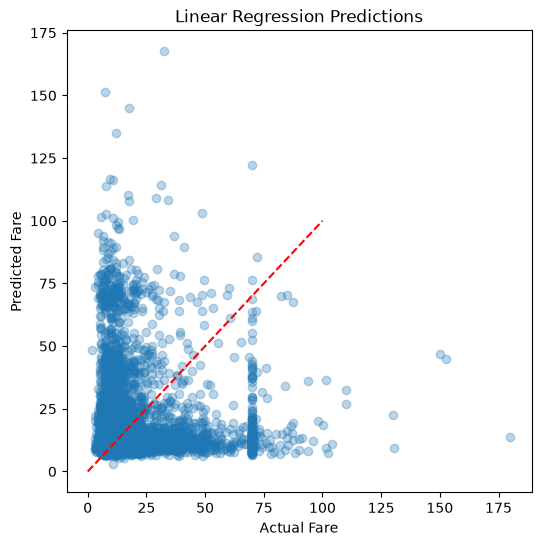

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test.sample(5000, random_state=42),
    predictions[:5000],
    alpha=0.3,
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Linear Regression Predictions")

plt.plot([0, 100], [0, 100], "r--")

plt.show()

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=50,
                random_state=42,
                max_depth=20,
                n_jobs=-1,
            ),
        ),
    ]
)


rf_pipeline.fit(X_train, y_train)
rf_predictions = rf_pipeline.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = mean_squared_error(y_test, rf_predictions) ** 0.5
rf_r2 = r2_score(y_test, rf_predictions)

print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²  : {rf_r2:.4f}")

MAE : 1.97
RMSE: 4.35
R²  : 0.9363


In [21]:
from xgboost import XGBRegressor
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                tree_method="hist",
            ),
        ),
    ]
)

xgb_pipeline.fit(X_train, y_train)
xgb_predictions = xgb_pipeline.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = mean_squared_error(y_test, xgb_predictions) ** 0.5
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f"MAE : {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"R²  : {xgb_r2:.4f}")

MAE : 1.99
RMSE: 4.92
R²  : 0.9184


In [22]:
from lightgbm import LGBMRegressor
lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMRegressor(
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                max_depth=-1,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                verbosity=-1,
            ),
        ),
    ]
)
lgbm_pipeline.fit(X_train, y_train)
lgbm_predictions = lgbm_pipeline.predict(X_test)
lgbm_mae = mean_absolute_error(y_test, lgbm_predictions)
lgbm_rmse = mean_squared_error(y_test, lgbm_predictions) ** 0.5
lgbm_r2 = r2_score(y_test, lgbm_predictions)

print(f"MAE : {lgbm_mae:.2f}")
print(f"RMSE: {lgbm_rmse:.2f}")
print(f"R²  : {lgbm_r2:.4f}")

/workspaces/logistics-ml-platform/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE : 1.97
RMSE: 4.79
R²  : 0.9226


In [23]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
    ],
    "MAE": [
        mae,
        rf_mae,
        xgb_mae,
        lgbm_mae,
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        xgb_rmse,
        lgbm_rmse,
    ],
    "R²": [
        r2,
        rf_r2,
        xgb_r2,
        lgbm_r2,
    ],
}).sort_values("R²", ascending=False)

results

,Model,MAE,RMSE,R²
1,Random Forest,1.967099,4.345436,0.936328
3,LightGBM,1.969037,4.789536,0.922648
2,XGBoost,1.988616,4.920426,0.918363
0,Linear Regression,2.558796,5.253690,0.906929


In [24]:
from pathlib import Path
import joblib

Path("models").mkdir(exist_ok=True)

joblib.dump(
    xgb_pipeline,
    "models/xgb_fare_predictor.joblib",
)

['models/xgb_fare_predictor.joblib']

In [25]:
loaded = joblib.load("models/xgb_fare_predictor.joblib")

loaded.predict(X_test.iloc[:5])

array([15.342183, 58.63787 , 43.08365 , 17.352615, 13.773662],
      dtype=float32)